<a href="https://colab.research.google.com/github/HARSHM904/radioml-modulation-classification/blob/main/Gunshotclassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("emrahaydemr/gunshot-audio-dataset")

print("Path to dataset files:", path)

100%|██████████| 380M/380M [00:02<00:00, 141MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/emrahaydemr/gunshot-audio-dataset/versions/1


In [2]:
import os
import librosa
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

base_path = "/root/.cache/kagglehub/datasets/emrahaydemr/gunshot-audio-dataset/versions/1"

# Merge M4 and M16 into one class
LABEL_MERGE = {"M4": "M4_M16", "M16": "M4_M16"}

def extract_features(y, sr, n_mfcc=40):
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    delta = librosa.feature.delta(mfccs)
    delta2 = librosa.feature.delta(mfccs, order=2)

    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(y)
    rms = librosa.feature.rms(y=y)

    feat = np.concatenate([
        mfccs.mean(axis=1), mfccs.std(axis=1),
        delta.mean(axis=1), delta.std(axis=1),
        delta2.mean(axis=1), delta2.std(axis=1),
        spectral_contrast.mean(axis=1), spectral_contrast.std(axis=1),
        centroid.mean(axis=1), centroid.std(axis=1),
        rolloff.mean(axis=1), rolloff.std(axis=1),
        bandwidth.mean(axis=1), bandwidth.std(axis=1),
        zcr.mean(axis=1), zcr.std(axis=1),
        rms.mean(axis=1), rms.std(axis=1),
    ])
    return feat

def augment_audio(y, sr):
    """Return a list of augmented versions of y."""
    augs = []
    # pitch shift
    augs.append(librosa.effects.pitch_shift(y, sr=sr, n_steps=np.random.uniform(-1.5, 1.5)))
    # time stretch
    rate = np.random.uniform(0.9, 1.1)
    y_stretch = librosa.effects.time_stretch(y, rate=rate)
    augs.append(y_stretch)
    # additive noise
    augs.append(y + np.random.normal(0, 0.005, y.shape))
    return augs

all_features = []
all_labels = []

gun_types = os.listdir(base_path)
print("Starting feature extraction (with augmentation)...")

for gun_type in gun_types:
    gun_type_path = os.path.join(base_path, gun_type)
    if not os.path.isdir(gun_type_path):
        continue

    label = LABEL_MERGE.get(gun_type, gun_type)
    print(f"Processing: {gun_type} -> {label}")

    for audio_file_name in os.listdir(gun_type_path):
        if not audio_file_name.endswith('.wav'):
            continue
        audio_file_path = os.path.join(gun_type_path, audio_file_name)

        try:
            y, sr = librosa.load(audio_file_path, sr=None)
            if y.ndim > 1:
                y = librosa.to_mono(y.T)

            # original sample
            all_features.append(extract_features(y, sr))
            all_labels.append(label)

            # augmented samples (3x more data per file)
            for y_aug in augment_audio(y, sr):
                all_features.append(extract_features(y_aug, sr))
                all_labels.append(label)

        except Exception as e:
            print(f"Error processing {audio_file_path}: {e}")

print("Feature extraction complete!")

features_df = pd.DataFrame(all_features)
labels_df = pd.DataFrame(all_labels, columns=['gun_type'])

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_labels = encoder.fit_transform(labels_df[['gun_type']])

print(f"\nShape of features dataset: {features_df.shape}")
print(f"Shape of encoded labels: {encoded_labels.shape}")
print(f"Classes: {encoder.categories_[0]}")

Starting feature extraction (with augmentation)...
Processing: AK-12 -> AK-12
Processing: M16 -> M4_M16
Processing: MG-42 -> MG-42
Processing: M4 -> M4_M16
Processing: MP5 -> MP5
Processing: M249 -> M249
Processing: IMI Desert Eagle -> IMI Desert Eagle
Processing: Zastava M92 -> Zastava M92
Processing: AK-47 -> AK-47
Feature extraction complete!

Shape of features dataset: (3404, 264)
Shape of encoded labels: (3404, 8)
Classes: ['AK-12' 'AK-47' 'IMI Desert Eagle' 'M249' 'M4_M16' 'MG-42' 'MP5'
 'Zastava M92']


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = features_df.values
y = encoded_labels

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# IMPORTANT: fit scaler on train only, apply to val/test
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (2042, 264), Val: (681, 264), Test: (681, 264)


In [4]:
from tensorflow import keras
from tensorflow.keras import layers, regularizers

n_features = X_train.shape[1]
n_classes = y_train.shape[1]

model = keras.Sequential([
    layers.Input(shape=(n_features,)),

    layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4), name="hidden_1"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.45),

    layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4), name="hidden_2"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.4),

    layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4), name="hidden_3"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.3),

    layers.Dense(n_classes, activation="softmax", name="output")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy", keras.metrics.TopKCategoricalAccuracy(k=2, name="top_2_accuracy"),
             keras.metrics.Precision(name="precision"), keras.metrics.Recall(name="recall")]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 256)            │        67,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,304 (434.78 KB)

 Trainable params: 110,408 (431.28 KB)

 Non-trainable params: 896 (3.50 KB)

In [5]:
from sklearn.utils.class_weight import compute_class_weight

y_train_labels = np.argmax(y_train, axis=1)
class_weights_arr = compute_class_weight('balanced', classes=np.unique(y_train_labels), y=y_train_labels)
class_weights = dict(enumerate(class_weights_arr))

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=20, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8),
    keras.callbacks.ModelCheckpoint("best_gunshot_model_v2.keras", monitor="val_accuracy", save_best_only=True),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.2316 - loss: 2.1745 - precision: 0.3732 - recall: 0.0504 - top_2_accuracy: 0.3913 - val_accuracy: 0.4714 - val_loss: 1.6672 - val_precision: 0.9386 - val_recall: 0.1571 - val_top_2_accuracy: 0.6050 - learning_rate: 5.0000e-04
Epoch 2/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3639 - loss: 1.7759 - precision: 0.7291 - recall: 0.1410 - top_2_accuracy: 0.5397 - val_accuracy: 0.5492 - val_loss: 1.5044 - val_precision: 0.9421 - val_recall: 0.2628 - val_top_2_accuracy: 0.7430 - learning_rate: 5.0000e-04
Epoch 3/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4417 - loss: 1.5949 - precision: 0.8122 - recall: 0.1885 - top_2_accuracy: 0.6263 - val_accuracy: 0.6373 - val_loss: 1.3921 - val_precision: 0.9406 - val_recall: 0.3025 - val_top_2_accuracy: 0.7871 - learning_rate: 5.0000e-04
Epoch 4/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5147 - loss: 1.4707 - precision: 0.8383 - recall: 0.2463 - 

In [6]:
test_loss, test_acc, test_top2, test_prec, test_recall = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9824 - loss: 0.5792 - precision: 0.9925 - recall: 0.9750 - top_2_accuracy: 0.9941
Test accuracy: 0.9824


In [7]:
from sklearn.metrics import classification_report
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_test_labels = np.argmax(y_test, axis=1)
print(classification_report(y_test_labels, y_test_labels, target_names=encoder.categories_[0]))

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
                  precision    recall  f1-score   support

           AK-12       1.00      1.00      1.00        78
           AK-47       1.00      1.00      1.00        58
IMI Desert Eagle       1.00      1.00      1.00        80
            M249       1.00      1.00      1.00        79
          M4_M16       1.00      1.00      1.00       160
           MG-42       1.00      1.00      1.00        80
             MP5       1.00      1.00      1.00        80
     Zastava M92       1.00      1.00      1.00        66

        accuracy                           1.00       681
       macro avg       1.00      1.00      1.00       681
    weighted avg       1.00      1.00      1.00       681



In [9]:
print(classification_report(y_test_labels, y_pred_labels, target_names=encoder.categories_[0]))

                  precision    recall  f1-score   support

           AK-12       1.00      1.00      1.00        78
           AK-47       0.98      1.00      0.99        58
IMI Desert Eagle       0.95      1.00      0.98        80
            M249       1.00      0.99      0.99        79
          M4_M16       0.97      0.98      0.98       160
           MG-42       0.98      1.00      0.99        80
             MP5       1.00      0.90      0.95        80
     Zastava M92       1.00      1.00      1.00        66

        accuracy                           0.98       681
       macro avg       0.99      0.98      0.98       681
    weighted avg       0.98      0.98      0.98       681



22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9824 - loss: 0.5792 - precision: 0.9925 - recall: 0.9750 - top_2_accuracy: 0.9941

Test Loss: 0.5792
Test Accuracy: 0.9824
Test Top-2 Accuracy: 0.9941
Test Precision: 0.9925
Test Recall: 0.9750
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

CLASSIFICATION REPORT
                  precision    recall  f1-score   support

           AK-12     1.0000    1.0000    1.0000        78
           AK-47     0.9831    1.0000    0.9915        58
IMI Desert Eagle     0.9524    1.0000    0.9756        80
            M249     1.0000    0.9873    0.9936        79
          M4_M16     0.9691    0.9812    0.9752       160
           MG-42     0.9756    1.0000    0.9877        80
             MP5     1.0000    0.9000    0.9474        80
     Zastava M92     1.0000    1.0000    1.0000        66

        accuracy                         0.9824       681
       macro avg     0.9850    0.9836    0.9839       681
    weighted avg     0.9828    0.9824    0.9822    

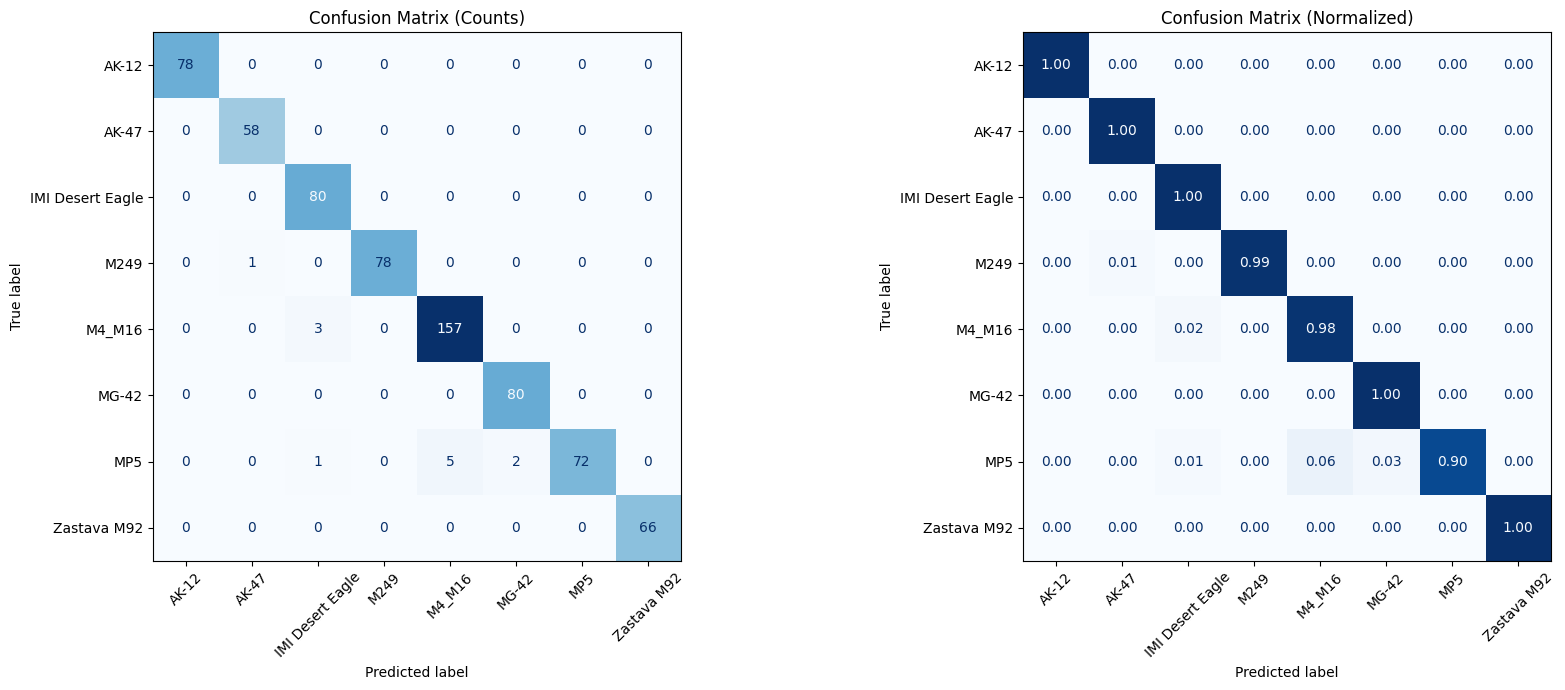

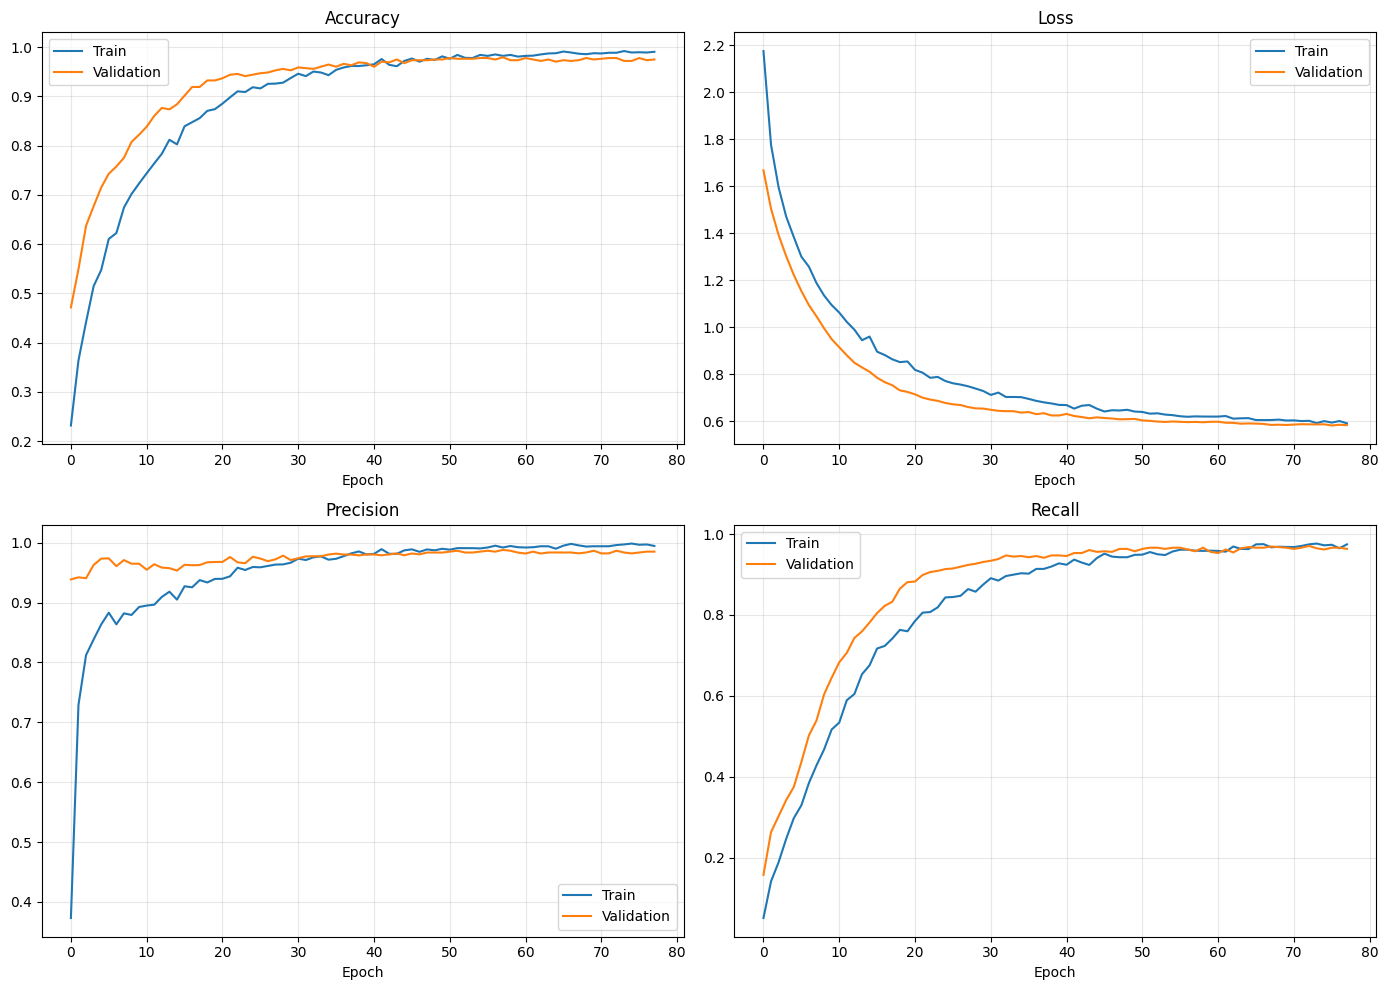

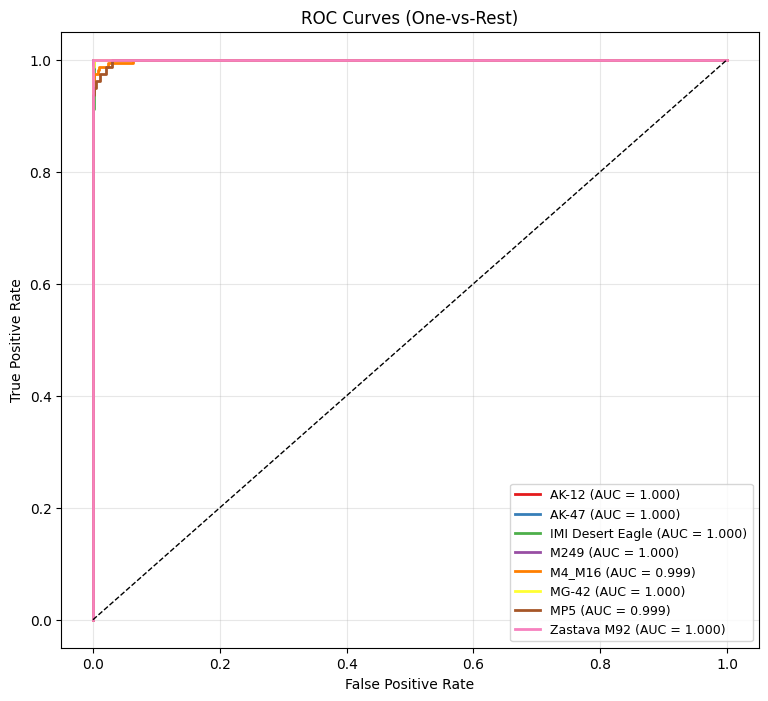

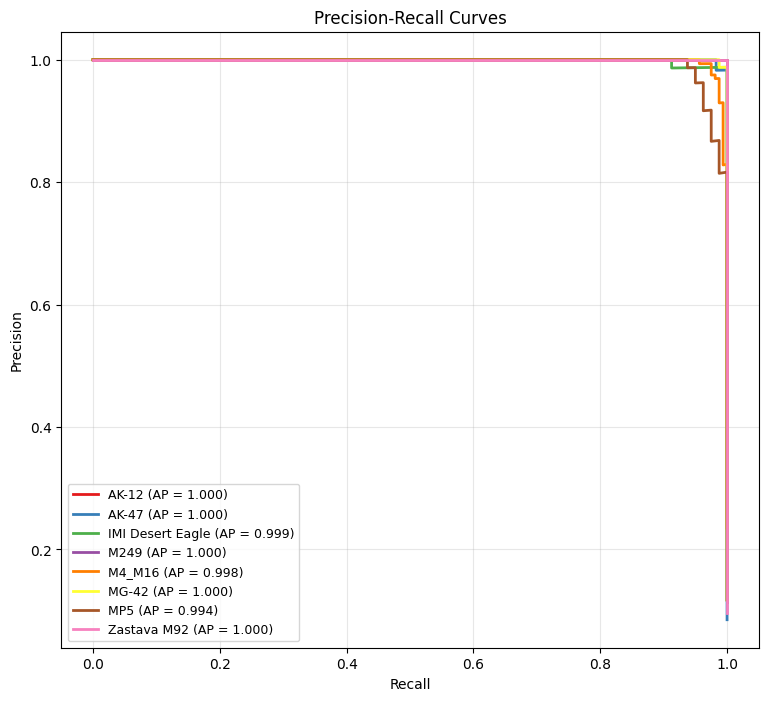

/tmp/ipykernel_523/872259325.py:141: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([confidences[y_test_labels == i] for i in range(n_classes)], labels=class_names)


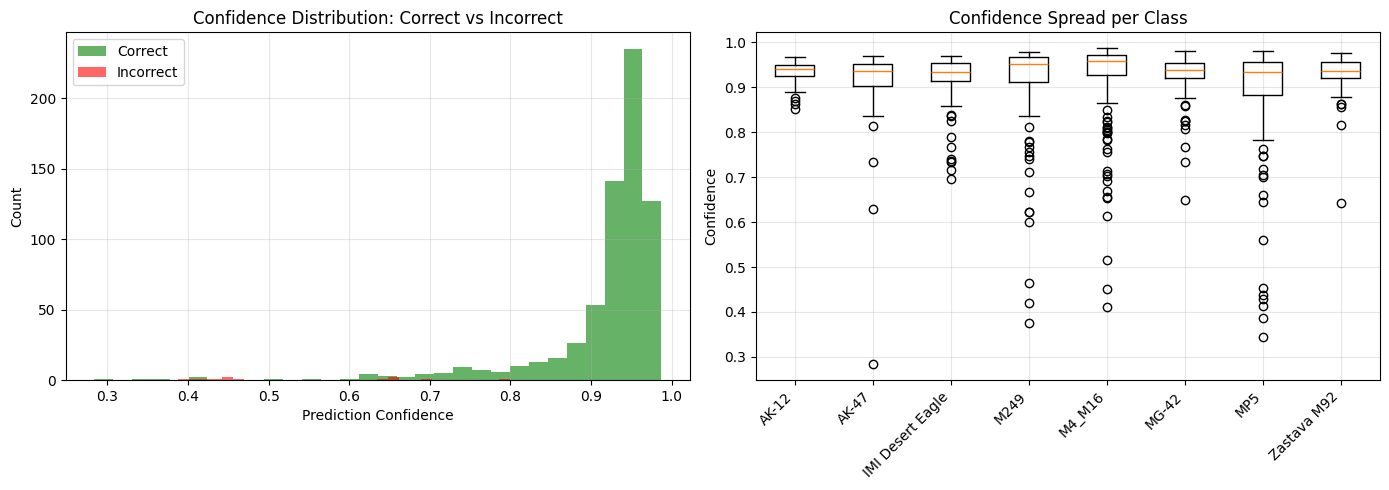


Average confidence: 0.9118
Avg confidence (correct): 0.9185
Avg confidence (incorrect): 0.5413

Total misclassified: 12 / 681

Misclassified samples:
  True=MP5                  Pred=M4_M16               Confidence=0.660
  True=M4_M16               Pred=IMI Desert Eagle     Confidence=0.452
  True=MP5                  Pred=MG-42                Confidence=0.414
  True=MP5                  Pred=M4_M16               Confidence=0.387
  True=MP5                  Pred=IMI Desert Eagle     Confidence=0.645
  True=MP5                  Pred=MG-42                Confidence=0.700
  True=M4_M16               Pred=IMI Desert Eagle     Confidence=0.799
  True=MP5                  Pred=M4_M16               Confidence=0.438
  True=MP5                  Pred=M4_M16               Confidence=0.428
  True=M249                 Pred=AK-47                Confidence=0.463
  True=MP5                  Pred=M4_M16               Confidence=0.454
  True=M4_M16               Pred=IMI Desert Eagle     Confidence=0.6

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
from itertools import cycle

# ============================================================
# 1. BASIC EVALUATION
# ============================================================
test_loss, test_acc, test_top2, test_prec, test_recall = model.evaluate(X_test, y_test, verbose=1)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Top-2 Accuracy: {test_top2:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall: {test_recall:.4f}")

# ============================================================
# 2. GET PREDICTIONS (correctly!)
# ============================================================
y_pred_probs = model.predict(X_test)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_test_labels = np.argmax(y_test, axis=1)   # ground truth, NOT compared to itself

class_names = encoder.categories_[0]

# ============================================================
# 3. CLASSIFICATION REPORT (correct version)
# ============================================================
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test_labels, y_pred_labels, target_names=class_names, digits=4))

# ============================================================
# 4. CONFUSION MATRIX (raw + normalized)
# ============================================================
cm = confusion_matrix(y_test_labels, y_pred_labels)
cm_norm = confusion_matrix(y_test_labels, y_pred_labels, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp1.plot(ax=axes[0], cmap='Blues', colorbar=False, xticks_rotation=45)
axes[0].set_title("Confusion Matrix (Counts)")

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp2.plot(ax=axes[1], cmap='Blues', colorbar=False, xticks_rotation=45, values_format='.2f')
axes[1].set_title("Confusion Matrix (Normalized)")

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 5. TRAINING HISTORY PLOTS
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(history.history['accuracy'], label='Train')
axes[0,0].plot(history.history['val_accuracy'], label='Validation')
axes[0,0].set_title('Accuracy'); axes[0,0].set_xlabel('Epoch'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(history.history['loss'], label='Train')
axes[0,1].plot(history.history['val_loss'], label='Validation')
axes[0,1].set_title('Loss'); axes[0,1].set_xlabel('Epoch'); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

axes[1,0].plot(history.history['precision'], label='Train')
axes[1,0].plot(history.history['val_precision'], label='Validation')
axes[1,0].set_title('Precision'); axes[1,0].set_xlabel('Epoch'); axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(history.history['recall'], label='Train')
axes[1,1].plot(history.history['val_recall'], label='Validation')
axes[1,1].set_title('Recall'); axes[1,1].set_xlabel('Epoch'); axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 6. ROC CURVES (one-vs-rest, per class)
# ============================================================
n_classes = len(class_names)
fpr, tpr, roc_auc = {}, {}, {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(9, 8))
colors = cycle(['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#ffff33','#a65628','#f781bf'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (One-vs-Rest)')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 7. PRECISION-RECALL CURVES (per class)
# ============================================================
plt.figure(figsize=(9, 8))
for i, color in zip(range(n_classes), colors):
    precision_i, recall_i, _ = precision_recall_curve(y_test[:, i], y_pred_probs[:, i])
    ap = average_precision_score(y_test[:, i], y_pred_probs[:, i])
    plt.plot(recall_i, precision_i, color=color, lw=2,
             label=f'{class_names[i]} (AP = {ap:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend(loc='lower left', fontsize=9)
plt.grid(alpha=0.3)
plt.savefig('pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 8. PREDICTION CONFIDENCE ANALYSIS
# ============================================================
confidences = np.max(y_pred_probs, axis=1)
correct_mask = (y_pred_labels == y_test_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(confidences[correct_mask], bins=30, alpha=0.6, label='Correct', color='green')
axes[0].hist(confidences[~correct_mask], bins=30, alpha=0.6, label='Incorrect', color='red')
axes[0].set_xlabel('Prediction Confidence')
axes[0].set_ylabel('Count')
axes[0].set_title('Confidence Distribution: Correct vs Incorrect')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].boxplot([confidences[y_test_labels == i] for i in range(n_classes)], labels=class_names)
axes[1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1].set_ylabel('Confidence')
axes[1].set_title('Confidence Spread per Class')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('confidence_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAverage confidence: {confidences.mean():.4f}")
print(f"Avg confidence (correct): {confidences[correct_mask].mean():.4f}")
print(f"Avg confidence (incorrect): {confidences[~correct_mask].mean():.4f}" if (~correct_mask).sum() > 0 else "No incorrect predictions")

# ============================================================
# 9. MISCLASSIFIED SAMPLES
# ============================================================
misclassified_idx = np.where(~correct_mask)[0]
print(f"\nTotal misclassified: {len(misclassified_idx)} / {len(y_test_labels)}")

if len(misclassified_idx) > 0:
    print("\nMisclassified samples:")
    for idx in misclassified_idx[:15]:
        true_c = class_names[y_test_labels[idx]]
        pred_c = class_names[y_pred_labels[idx]]
        conf = confidences[idx]
        print(f"  True={true_c:20s} Pred={pred_c:20s} Confidence={conf:.3f}")

In [11]:
# Did you split BEFORE or AFTER augmenting?
# If AFTER (augment-then-split), you likely have leakage.
# Check: how many total samples do you have vs original file count?
print(f"Total feature samples: {len(all_features)}")
print(f"Expected if no augmentation: ~851")
print(f"Expected if augmented 4x (orig + 3 augs): ~{851*4}")

Total feature samples: 3404
Expected if no augmentation: ~851
Expected if augmented 4x (orig + 3 augs): ~3404


In [12]:
import os
import librosa
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

base_path = "/root/.cache/kagglehub/datasets/emrahaydemr/gunshot-audio-dataset/versions/1"
LABEL_MERGE = {"M4": "M4_M16", "M16": "M4_M16"}

def extract_features(y, sr, n_mfcc=40):
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    delta = librosa.feature.delta(mfccs)
    delta2 = librosa.feature.delta(mfccs, order=2)
    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(y)
    rms = librosa.feature.rms(y=y)
    return np.concatenate([
        mfccs.mean(axis=1), mfccs.std(axis=1),
        delta.mean(axis=1), delta.std(axis=1),
        delta2.mean(axis=1), delta2.std(axis=1),
        spectral_contrast.mean(axis=1), spectral_contrast.std(axis=1),
        centroid.mean(axis=1), centroid.std(axis=1),
        rolloff.mean(axis=1), rolloff.std(axis=1),
        bandwidth.mean(axis=1), bandwidth.std(axis=1),
        zcr.mean(axis=1), zcr.std(axis=1),
        rms.mean(axis=1), rms.std(axis=1),
    ])

def augment_audio(y, sr):
    augs = []
    augs.append(librosa.effects.pitch_shift(y, sr=sr, n_steps=np.random.uniform(-1.5, 1.5)))
    augs.append(librosa.effects.time_stretch(y, rate=np.random.uniform(0.9, 1.1)))
    augs.append(y + np.random.normal(0, 0.005, y.shape))
    return augs

# ---- STEP 1: collect file paths + labels FIRST, no audio loaded yet ----
file_records = []
for gun_type in os.listdir(base_path):
    gun_type_path = os.path.join(base_path, gun_type)
    if not os.path.isdir(gun_type_path):
        continue
    label = LABEL_MERGE.get(gun_type, gun_type)
    for f in os.listdir(gun_type_path):
        if f.endswith('.wav'):
            file_records.append((os.path.join(gun_type_path, f), label))

paths = [r[0] for r in file_records]
labels = [r[1] for r in file_records]

# ---- STEP 2: split on FILE IDENTITY before any augmentation ----
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    paths, labels, test_size=0.4, random_state=42, stratify=labels
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels
)

print(f"Files -> train: {len(train_paths)}, val: {len(val_paths)}, test: {len(test_paths)}")

# ---- STEP 3: augment ONLY train; val/test get real, unaugmented audio only ----
def process_split(paths, labels, augment=False):
    X, y = [], []
    for path, label in zip(paths, labels):
        try:
            y_audio, sr = librosa.load(path, sr=None)
            if y_audio.ndim > 1:
                y_audio = librosa.to_mono(y_audio.T)
            X.append(extract_features(y_audio, sr))
            y.append(label)
            if augment:
                for y_aug in augment_audio(y_audio, sr):
                    X.append(extract_features(y_aug, sr))
                    y.append(label)
        except Exception as e:
            print(f"Error on {path}: {e}")
    return X, y

print("Processing train (with augmentation)...")
X_train_feat, y_train_lab = process_split(train_paths, train_labels, augment=True)
print("Processing val (no augmentation)...")
X_val_feat, y_val_lab = process_split(val_paths, val_labels, augment=False)
print("Processing test (no augmentation)...")
X_test_feat, y_test_lab = process_split(test_paths, test_labels, augment=False)

print(f"\nTrain: {len(X_train_feat)}, Val: {len(X_val_feat)}, Test: {len(X_test_feat)}")

# ---- STEP 4: encode labels (fit encoder on TRAIN labels only, transform others) ----
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
y_train = encoder.fit_transform(pd.DataFrame(y_train_lab, columns=['gun_type']))
y_val = encoder.transform(pd.DataFrame(y_val_lab, columns=['gun_type']))
y_test = encoder.transform(pd.DataFrame(y_test_lab, columns=['gun_type']))

X_train = np.array(X_train_feat)
X_val = np.array(X_val_feat)
X_test = np.array(X_test_feat)

# ---- STEP 5: scale (fit on train only) ----
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"\nFinal shapes -> X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")
print(f"Classes: {encoder.categories_[0]}")

Files -> train: 510, val: 170, test: 171
Processing train (with augmentation)...
Processing val (no augmentation)...
Processing test (no augmentation)...

Train: 2040, Val: 170, Test: 171

Final shapes -> X_train: (2040, 264), X_val: (170, 264), X_test: (171, 264)
Classes: ['AK-12' 'AK-47' 'IMI Desert Eagle' 'M249' 'M4_M16' 'MG-42' 'MP5'
 'Zastava M92']


In [13]:
from tensorflow import keras
from tensorflow.keras import layers, regularizers

n_features = X_train.shape[1]
n_classes = y_train.shape[1]

model = keras.Sequential([
    layers.Input(shape=(n_features,)),

    layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4), name="hidden_1"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.45),

    layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4), name="hidden_2"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.4),

    layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4), name="hidden_3"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.3),

    layers.Dense(n_classes, activation="softmax", name="output")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy", keras.metrics.TopKCategoricalAccuracy(k=2, name="top_2_accuracy"),
             keras.metrics.Precision(name="precision"), keras.metrics.Recall(name="recall")]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 256)            │        67,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,304 (434.78 KB)

 Trainable params: 110,408 (431.28 KB)

 Non-trainable params: 896 (3.50 KB)

In [14]:
from sklearn.utils.class_weight import compute_class_weight

y_train_int = np.argmax(y_train, axis=1)
class_weights_arr = compute_class_weight(
    'balanced', classes=np.unique(y_train_int), y=y_train_int
)
class_weights = dict(enumerate(class_weights_arr))

for i, cls in enumerate(encoder.categories_[0]):
    print(f"{cls}: {class_weights_arr[i]:.3f}")

AK-12: 1.081
AK-47: 1.483
IMI Desert Eagle: 1.062
M249: 1.081
M4_M16: 0.531
MG-42: 1.062
MP5: 1.062
Zastava M92: 1.301


In [15]:
from tensorflow import keras

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=20, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=8, min_lr=1e-6
    ),
    keras.callbacks.ModelCheckpoint(
        "best_gunshot_model_v3.keras", monitor="val_accuracy", save_best_only=True
    ),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.1995 - loss: 2.3255 - precision: 0.2459 - recall: 0.0441 - top_2_accuracy: 0.3387 - val_accuracy: 0.4412 - val_loss: 1.6814 - val_precision: 1.0000 - val_recall: 0.1471 - val_top_2_accuracy: 0.6176 - learning_rate: 5.0000e-04
Epoch 2/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3554 - loss: 1.7936 - precision: 0.6775 - recall: 0.1225 - top_2_accuracy: 0.5441 - val_accuracy: 0.5765 - val_loss: 1.4365 - val_precision: 0.9750 - val_recall: 0.2294 - val_top_2_accuracy: 0.7706 - learning_rate: 5.0000e-04
Epoch 3/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4475 - loss: 1.5813 - precision: 0.7590 - recall: 0.1961 - top_2_accuracy: 0.6515 - val_accuracy: 0.6471 - val_loss: 1.3060 - val_precision: 0.9434 - val_recall: 0.2941 - val_top_2_accuracy: 0.8529 - learning_rate: 5.0000e-04
Epoch 4/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5407 - loss: 1.4364 - precision: 0.8401 - recall: 0.2549 - to

In [16]:
# ============================================================
# 1. BASIC EVALUATION
# ============================================================
test_loss, test_acc, test_top2, test_prec, test_recall = model.evaluate(X_test, y_test, verbose=1)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Top-2 Accuracy: {test_top2:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall: {test_recall:.4f}")

# ============================================================
# 2. PREDICTIONS
# ============================================================
y_pred_probs = model.predict(X_test)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_test_labels = np.argmax(y_test, axis=1)
class_names = encoder.categories_[0]

# ============================================================
# 3. CLASSIFICATION REPORT
# ============================================================
from sklearn.metrics import classification_report
print("\n" + "="*60)
print("CLASSIFICATION REPORT (leak-free test set)")
print("="*60)
print(classification_report(y_test_labels, y_pred_labels, target_names=class_names, digits=4))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8889 - loss: 0.7912 - precision: 0.9241 - recall: 0.8538 - top_2_accuracy: 0.9649

Test Loss: 0.7912
Test Accuracy: 0.8889
Test Top-2 Accuracy: 0.9649
Test Precision: 0.9241
Test Recall: 0.8538
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

CLASSIFICATION REPORT (leak-free test set)
                  precision    recall  f1-score   support

           AK-12     1.0000    1.0000    1.0000        20
           AK-47     1.0000    0.9286    0.9630        14
IMI Desert Eagle     0.8000    0.8000    0.8000        20
            M249     0.8421    0.8000    0.8205        20
          M4_M16     0.9000    0.9000    0.9000        40
           MG-42     1.0000    0.9000    0.9474        20
             MP5     0.6667    0.8000    0.7273        20
     Zastava M92     1.0000    1.0000    1.0000        17

        accuracy                         0.8889       171
       macro avg     0.9011    0.8911    0.8948       171
    weighted avg     0.8958    0

In [17]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test_labels, y_pred_labels)
mp5_idx = list(class_names).index('MP5')
print(f"What gets predicted as MP5 (false positives):")
for i, name in enumerate(class_names):
    if i != mp5_idx and cm[i, mp5_idx] > 0:
        print(f"  {name} -> MP5: {cm[i, mp5_idx]} times")

What gets predicted as MP5 (false positives):
  IMI Desert Eagle -> MP5: 2 times
  M249 -> MP5: 3 times
  M4_M16 -> MP5: 3 times


In [18]:
# Check confidence on these specific errors
for i in range(len(y_test_labels)):
    true_c = class_names[y_test_labels[i]]
    pred_c = class_names[y_pred_labels[i]]
    if pred_c == 'MP5' and true_c != 'MP5':
        conf = y_pred_probs[i].max()
        print(f"True={true_c:20s} Pred=MP5  Confidence={conf:.3f}")

True=M4_M16               Pred=MP5  Confidence=0.909
True=M4_M16               Pred=MP5  Confidence=0.909
True=M249                 Pred=MP5  Confidence=0.569
True=IMI Desert Eagle     Pred=MP5  Confidence=0.398
True=M4_M16               Pred=MP5  Confidence=0.920
True=M249                 Pred=MP5  Confidence=0.382
True=IMI Desert Eagle     Pred=MP5  Confidence=0.836
True=M249                 Pred=MP5  Confidence=0.522


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
TEST SET METRICS
timestamp: 2026-07-08T03:48:25.538652
test_loss: 0.7912411093711853
test_accuracy: 0.8888888955116272
test_top2_accuracy: 0.9649122953414917
test_precision: 0.9240506291389465
test_recall: 0.8538011908531189
test_f1_macro: 0.8947646164751428
test_f1_weighted: 0.8911377827967548
n_train_samples: 2040
n_val_samples: 170
n_test_samples: 171
n_classes: 8
class_names: ['AK-12', 'AK-47', 'IMI Desert Eagle', 'M249', 'M4_M16', 'MG-42', 'MP5', 'Zastava M92']

CLASSIFICATION REPORT
                  precision    recall  f1-score   support

           AK-12     1.0000    1.0000    1.0000        20
           AK-47     1.0000    0.9286    0.9630        14
IMI Desert Eagle     0.8000    0.8000    0.8000        20
            M249     0.8421    0.8000    0.8205        20
          M4_M16     0.9000    0.9000    0.9000        40
           MG-42     1.0000    0.9000    0.9474        20
             MP5     0.6667    0.8000    0.7273        20
   

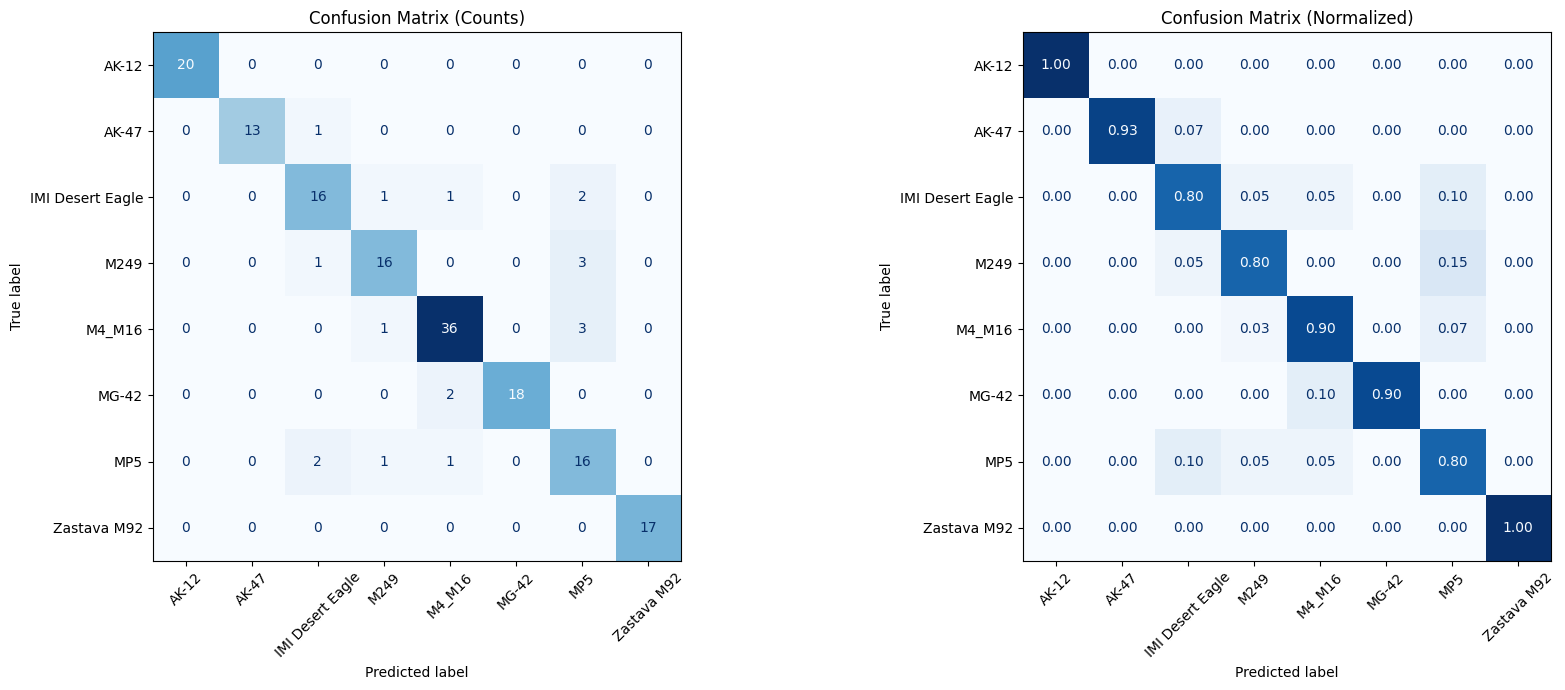

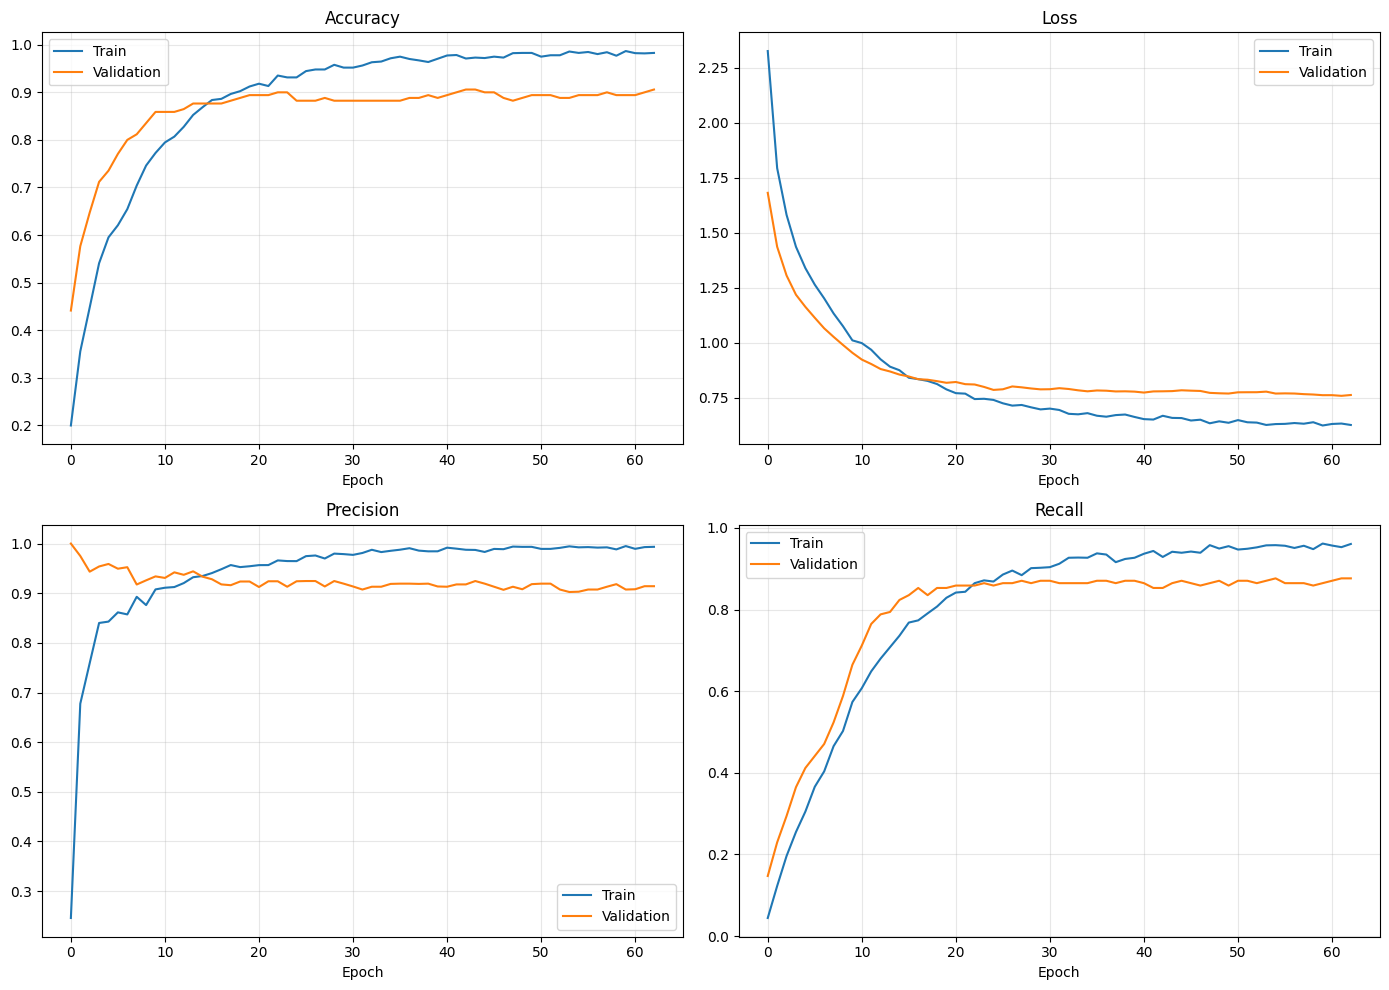

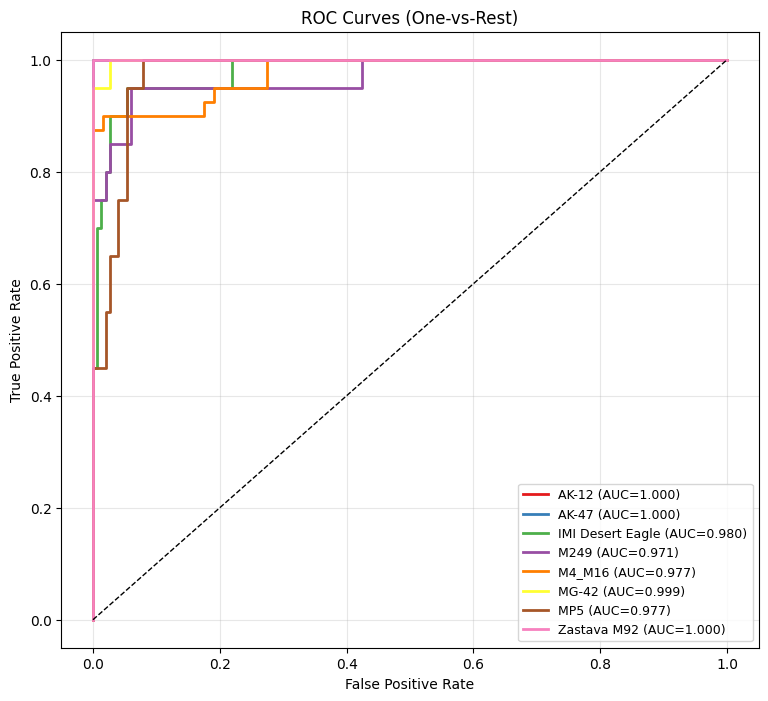

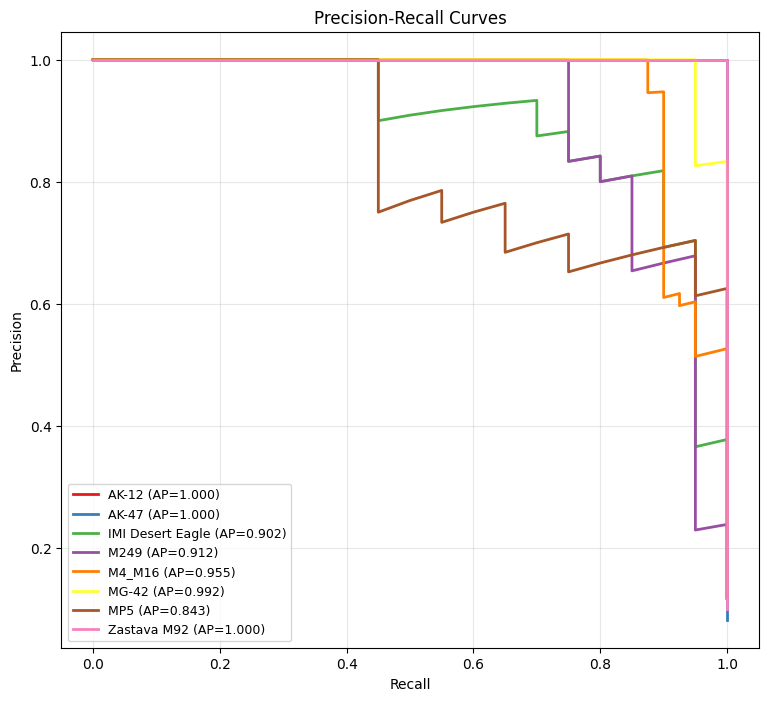

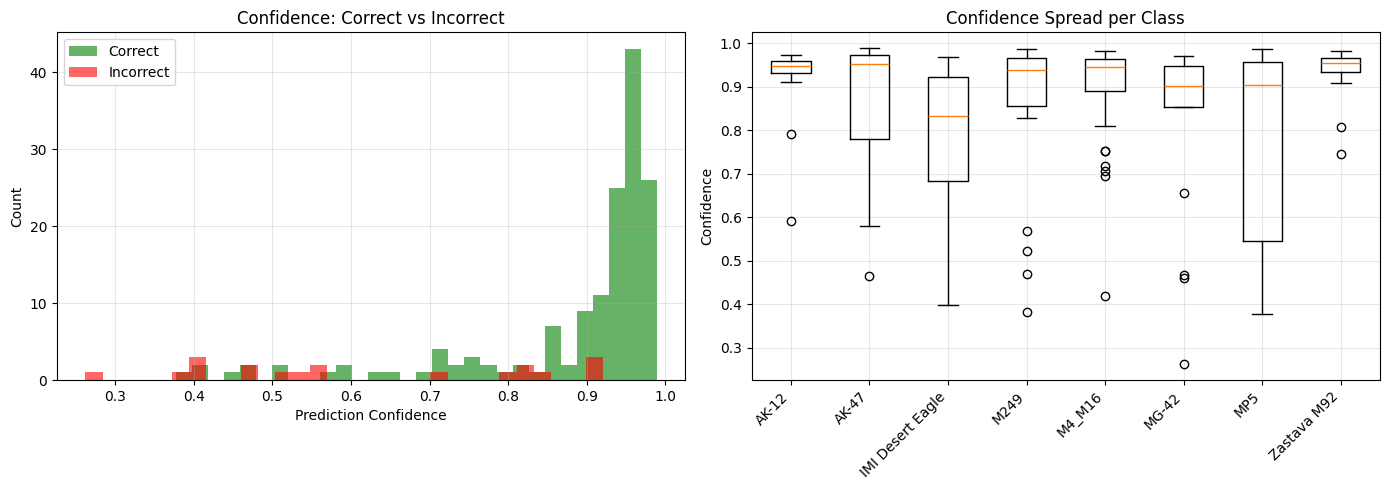


Total misclassified: 19 / 171
  True=MP5                  Pred=M249                 Conf=0.705
  True=M249                 Pred=IMI Desert Eagle     Conf=0.828
  True=M4_M16               Pred=MP5                  Conf=0.909
  True=M4_M16               Pred=MP5                  Conf=0.909
  True=MP5                  Pred=IMI Desert Eagle     Conf=0.399
  True=M249                 Pred=MP5                  Conf=0.569
  True=IMI Desert Eagle     Pred=MP5                  Conf=0.398
  True=M4_M16               Pred=MP5                  Conf=0.920
  True=M249                 Pred=MP5                  Conf=0.382
  True=MG-42                Pred=M4_M16               Conf=0.467
  True=IMI Desert Eagle     Pred=MP5                  Conf=0.836
  True=MG-42                Pred=M4_M16               Conf=0.262
  True=M249                 Pred=MP5                  Conf=0.522
  True=MP5                  Pred=M4_M16               Conf=0.400
  True=AK-47                Pred=IMI Desert Eagle     Conf=

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    accuracy_score, f1_score
)
from itertools import cycle

# ============================================================
# SETUP
# ============================================================
import os
os.makedirs('eval_outputs', exist_ok=True)

class_names = encoder.categories_[0]
n_classes = len(class_names)

y_pred_probs = model.predict(X_test)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

# ============================================================
# 1. BASIC METRICS
# ============================================================
test_loss, test_acc, test_top2, test_prec, test_recall = model.evaluate(X_test, y_test, verbose=0)

metrics_summary = {
    "timestamp": datetime.now().isoformat(),
    "test_loss": float(test_loss),
    "test_accuracy": float(test_acc),
    "test_top2_accuracy": float(test_top2),
    "test_precision": float(test_prec),
    "test_recall": float(test_recall),
    "test_f1_macro": float(f1_score(y_test_labels, y_pred_labels, average='macro')),
    "test_f1_weighted": float(f1_score(y_test_labels, y_pred_labels, average='weighted')),
    "n_train_samples": int(X_train.shape[0]),
    "n_val_samples": int(X_val.shape[0]),
    "n_test_samples": int(X_test.shape[0]),
    "n_classes": n_classes,
    "class_names": class_names.tolist(),
}

print("="*60)
print("TEST SET METRICS")
print("="*60)
for k, v in metrics_summary.items():
    print(f"{k}: {v}")

# ============================================================
# 2. CLASSIFICATION REPORT (text + saved dict)
# ============================================================
report_text = classification_report(y_test_labels, y_pred_labels, target_names=class_names, digits=4)
report_dict = classification_report(y_test_labels, y_pred_labels, target_names=class_names, digits=4, output_dict=True)

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(report_text)

with open('eval_outputs/classification_report.txt', 'w') as f:
    f.write(report_text)
with open('eval_outputs/classification_report.json', 'w') as f:
    json.dump(report_dict, f, indent=2)
with open('eval_outputs/metrics_summary.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)

# ============================================================
# 3. CONFUSION MATRICES
# ============================================================
cm = confusion_matrix(y_test_labels, y_pred_labels)
cm_norm = confusion_matrix(y_test_labels, y_pred_labels, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=axes[0], cmap='Blues', colorbar=False, xticks_rotation=45)
axes[0].set_title("Confusion Matrix (Counts)")
ConfusionMatrixDisplay(cm_norm, display_labels=class_names).plot(ax=axes[1], cmap='Blues', colorbar=False, xticks_rotation=45, values_format='.2f')
axes[1].set_title("Confusion Matrix (Normalized)")
plt.tight_layout()
plt.savefig('eval_outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 4. TRAINING HISTORY
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, metric, title in zip(
    axes.flat,
    ['accuracy', 'loss', 'precision', 'recall'],
    ['Accuracy', 'Loss', 'Precision', 'Recall']
):
    ax.plot(history.history[metric], label='Train')
    ax.plot(history.history[f'val_{metric}'], label='Validation')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('eval_outputs/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 5. ROC CURVES
# ============================================================
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(9, 8))
colors = cycle(['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#ffff33','#a65628','#f781bf'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'{class_names[i]} (AUC={roc_auc[i]:.3f})')
plt.plot([0,1],[0,1],'k--',lw=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves (One-vs-Rest)'); plt.legend(loc='lower right', fontsize=9); plt.grid(alpha=0.3)
plt.savefig('eval_outputs/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 6. PRECISION-RECALL CURVES
# ============================================================
plt.figure(figsize=(9, 8))
for i, color in zip(range(n_classes), colors):
    p, r, _ = precision_recall_curve(y_test[:, i], y_pred_probs[:, i])
    ap = average_precision_score(y_test[:, i], y_pred_probs[:, i])
    plt.plot(r, p, color=color, lw=2, label=f'{class_names[i]} (AP={ap:.3f})')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curves'); plt.legend(loc='lower left', fontsize=9); plt.grid(alpha=0.3)
plt.savefig('eval_outputs/pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 7. CONFIDENCE ANALYSIS
# ============================================================
confidences = np.max(y_pred_probs, axis=1)
correct_mask = (y_pred_labels == y_test_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(confidences[correct_mask], bins=30, alpha=0.6, label='Correct', color='green')
axes[0].hist(confidences[~correct_mask], bins=30, alpha=0.6, label='Incorrect', color='red')
axes[0].set_xlabel('Prediction Confidence'); axes[0].set_ylabel('Count')
axes[0].set_title('Confidence: Correct vs Incorrect'); axes[0].legend(); axes[0].grid(alpha=0.3)

box_data = [confidences[y_test_labels == i] for i in range(n_classes)]
axes[1].boxplot(box_data, tick_labels=class_names)
axes[1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1].set_ylabel('Confidence'); axes[1].set_title('Confidence Spread per Class'); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('eval_outputs/confidence_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 8. MISCLASSIFIED SAMPLES LOG
# ============================================================
misclassified_idx = np.where(~correct_mask)[0]
misclass_records = []
for idx in misclassified_idx:
    misclass_records.append({
        "index": int(idx),
        "true_class": class_names[y_test_labels[idx]],
        "predicted_class": class_names[y_pred_labels[idx]],
        "confidence": float(confidences[idx])
    })

with open('eval_outputs/misclassified_samples.json', 'w') as f:
    json.dump(misclass_records, f, indent=2)

print(f"\nTotal misclassified: {len(misclassified_idx)} / {len(y_test_labels)}")
for r in misclass_records:
    print(f"  True={r['true_class']:20s} Pred={r['predicted_class']:20s} Conf={r['confidence']:.3f}")

print("\nAll outputs saved to eval_outputs/")
print(os.listdir('eval_outputs'))

In [20]:
readme_metrics = f"""
## Model Evaluation Results

**Dataset:** {metrics_summary['n_train_samples']} train / {metrics_summary['n_val_samples']} val / {metrics_summary['n_test_samples']} test samples (leak-free split — augmentation applied only after splitting on original file identity)

**Classes ({n_classes}):** {', '.join(class_names)} (M4 and M16 merged due to acoustic similarity)

### Test Set Performance
| Metric | Score |
|---|---|
| Accuracy | {test_acc:.4f} |
| Top-2 Accuracy | {test_top2:.4f} |
| Precision | {test_prec:.4f} |
| Recall | {test_recall:.4f} |
| F1 (macro) | {metrics_summary['test_f1_macro']:.4f} |
| F1 (weighted) | {metrics_summary['test_f1_weighted']:.4f} |

### Per-Class F1 Scores
| Class | Precision | Recall | F1 |
|---|---|---|---|
"""
for cls in class_names:
    r = report_dict[cls]
    readme_metrics += f"| {cls} | {r['precision']:.3f} | {r['recall']:.3f} | {r['f1-score']:.3f} |\n"

with open('eval_outputs/README_metrics_section.md', 'w') as f:
    f.write(readme_metrics)

print(readme_metrics)


## Model Evaluation Results

**Dataset:** 2040 train / 170 val / 171 test samples (leak-free split — augmentation applied only after splitting on original file identity)

**Classes (8):** AK-12, AK-47, IMI Desert Eagle, M249, M4_M16, MG-42, MP5, Zastava M92 (M4 and M16 merged due to acoustic similarity)

### Test Set Performance
| Metric | Score |
|---|---|
| Accuracy | 0.8889 |
| Top-2 Accuracy | 0.9649 |
| Precision | 0.9241 |
| Recall | 0.8538 |
| F1 (macro) | 0.8948 |
| F1 (weighted) | 0.8911 |

### Per-Class F1 Scores
| Class | Precision | Recall | F1 |
|---|---|---|---|
| AK-12 | 1.000 | 1.000 | 1.000 |
| AK-47 | 1.000 | 0.929 | 0.963 |
| IMI Desert Eagle | 0.800 | 0.800 | 0.800 |
| M249 | 0.842 | 0.800 | 0.821 |
| M4_M16 | 0.900 | 0.900 | 0.900 |
| MG-42 | 1.000 | 0.900 | 0.947 |
| MP5 | 0.667 | 0.800 | 0.727 |
| Zastava M92 | 1.000 | 1.000 | 1.000 |

